## Import

In [ ]:
import os
import nanonis_reader as nr
print(f'nanonis_reader loaded from: {nr.__file__}')
from nanonis_reader.cmap_custom import bwr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

plt.rcParams['font.family'] = 'arial'
plt.rcParams['font.size'] = 7
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams["xtick.top"] = True 
plt.rcParams["ytick.right"] = True
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = [86.0/25.4, 86.0/25.4]

win = 'D:/OneDrive/Data/230922_TNS_STM6/'
mac = os.path.expanduser('~/Library/CloudStorage/OneDrive-Personal/Data/230922_TNS_STM6/')
dir = (win if os.path.exists(win) else mac)

## Topo example

C:\Users\kdwpu\AppData\Local\Temp\ipykernel_15384\4050637340.py:2: DeprecationWarning: topography.get_z() is deprecated. Call processing methods directly: d.topo.raw(), d.topo.subtract_linear_fit(), etc.
  z = data_topo.topo.get_z()


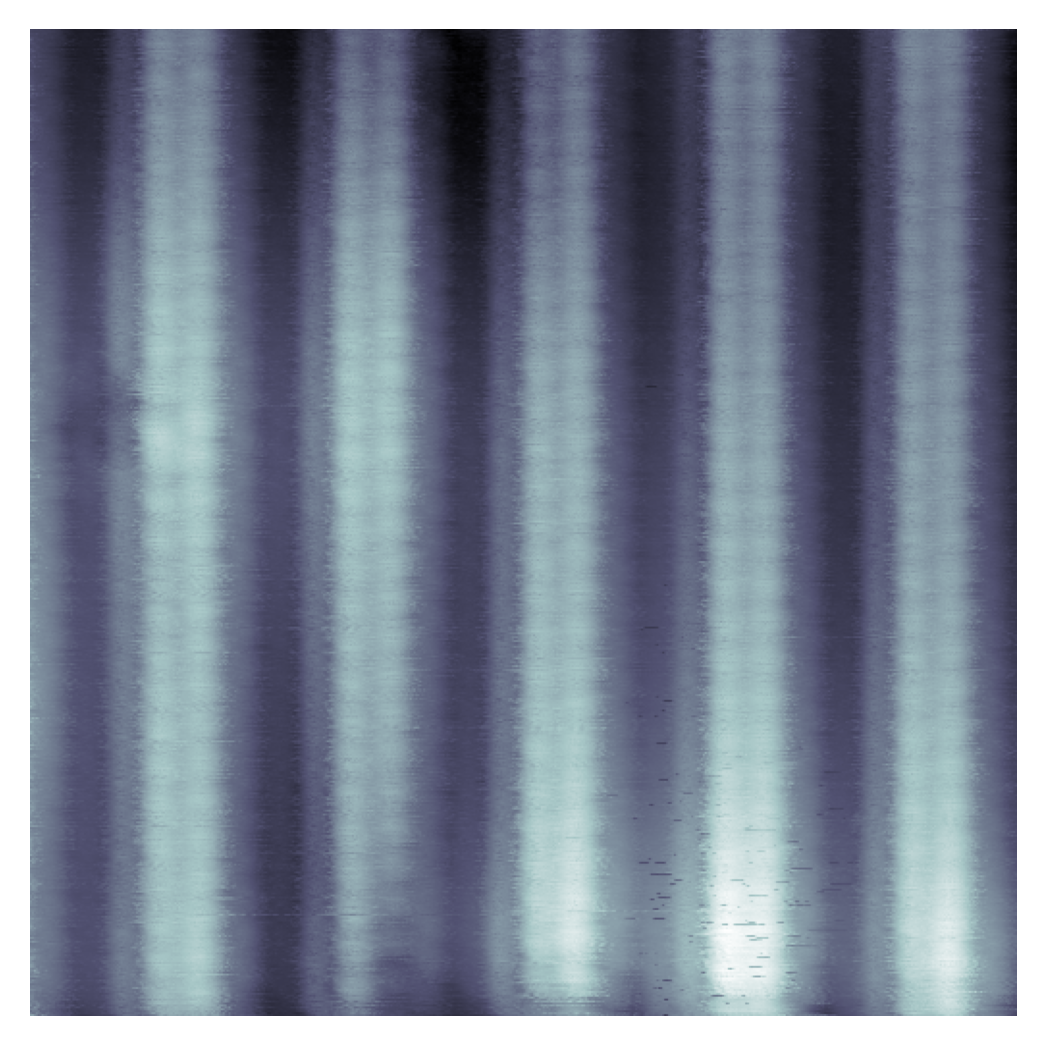

In [2]:
data_topo = nr.load(dir + "TNS_STM6_#117_2938.sxm")
z = data_topo.topo.get_z()

fig, axs = plt.subplots(1, 1, figsize=(86/25.4, 86/25.4))
axs.imshow(z, cmap='bone', origin='lower')
axs.set_axis_off()
fig.tight_layout(pad=0.5)

## STS example (.dat)

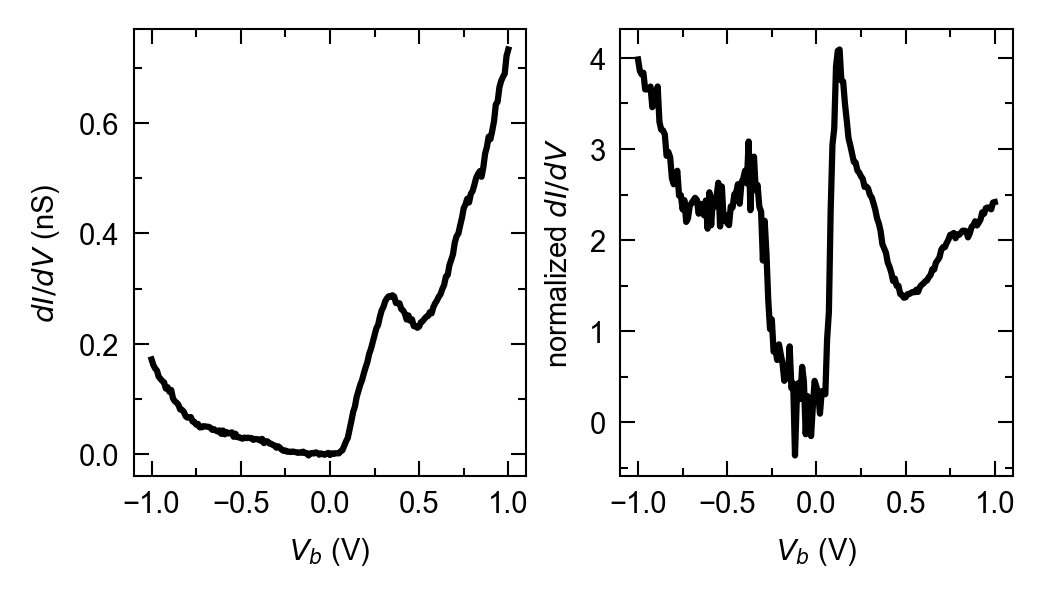

In [3]:
data_sts = nr.load(dir + "TNS_STM6_#117_1154.dat")
v, didv_scaled = data_sts.spec.didv_scaled()
v_n, didv_norm = data_sts.spec.didv_normalized()

fig, axs = plt.subplots(1, 2, figsize=(86/25.4, 48/25.4))
axs[0].plot(v, didv_scaled * 1e9, color='k')
axs[1].plot(v_n, didv_norm, color='k')

axs[0].set_xlabel('$V_b$ (V)')
axs[0].set_ylabel('$dI/dV$ (nS)')
axs[0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0].xaxis.set_minor_locator(AutoMinorLocator(2))
axs[0].yaxis.set_minor_locator(AutoMinorLocator(2))

axs[1].set_xlabel('$V_b$ (V)')
axs[1].set_ylabel('normalized $dI/dV$')
axs[1].xaxis.set_major_locator(MultipleLocator(0.5))
axs[1].xaxis.set_minor_locator(AutoMinorLocator(2))
axs[1].yaxis.set_minor_locator(AutoMinorLocator(2))

fig.tight_layout(pad=0.5)

## STS example (.dat) — new API

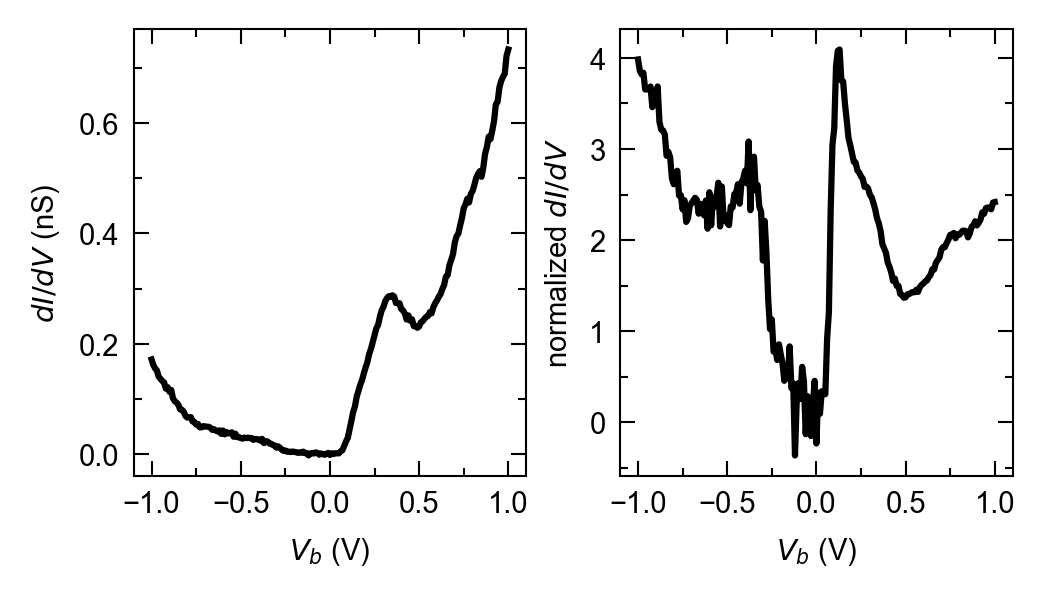

In [4]:
# New API: d.sts.scaled() / d.sts.normalized()
v2, didv_scaled2 = data_sts.sts.scaled()
v_n2, didv_norm2 = data_sts.sts.normalized()

fig, axs = plt.subplots(1, 2, figsize=(86/25.4, 48/25.4))
axs[0].plot(v2, didv_scaled2 * 1e9, color='k')
axs[1].plot(v_n2, didv_norm2, color='k')

axs[0].set_xlabel('$V_b$ (V)')
axs[0].set_ylabel('$dI/dV$ (nS)')
axs[0].xaxis.set_major_locator(MultipleLocator(0.5))
axs[0].xaxis.set_minor_locator(AutoMinorLocator(2))
axs[0].yaxis.set_minor_locator(AutoMinorLocator(2))

axs[1].set_xlabel('$V_b$ (V)')
axs[1].set_ylabel('normalized $dI/dV$')
axs[1].xaxis.set_major_locator(MultipleLocator(0.5))
axs[1].xaxis.set_minor_locator(AutoMinorLocator(2))
axs[1].yaxis.set_minor_locator(AutoMinorLocator(2))

fig.tight_layout(pad=0.5)

## I-z spectrum example (.dat)

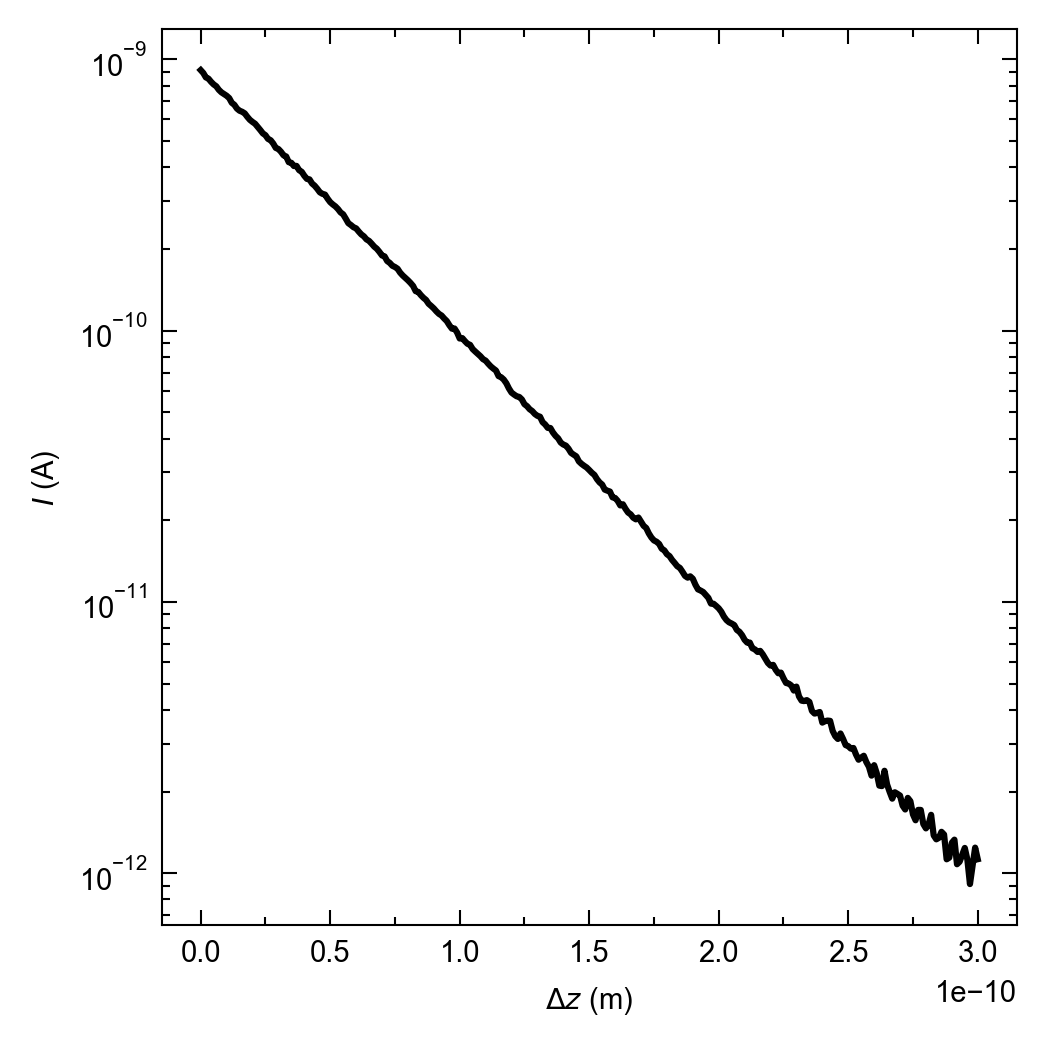

In [5]:
data_iz = nr.load(dir + "TNS_STM6_#117_4962.dat")
z, current = data_iz.z_spec.get_iz()

fig, axs = plt.subplots(1, 1, figsize=(86/25.4, 86/25.4))
axs.plot(z, current, color='k')
axs.set_yscale('log')
axs.set_xlabel(r'$\Delta z$ (m)')
axs.set_ylabel('$I$ (A)')
axs.xaxis.set_minor_locator(AutoMinorLocator(2))
fig.tight_layout(pad=0.5)

## I-z spectrum example (.dat) — new API

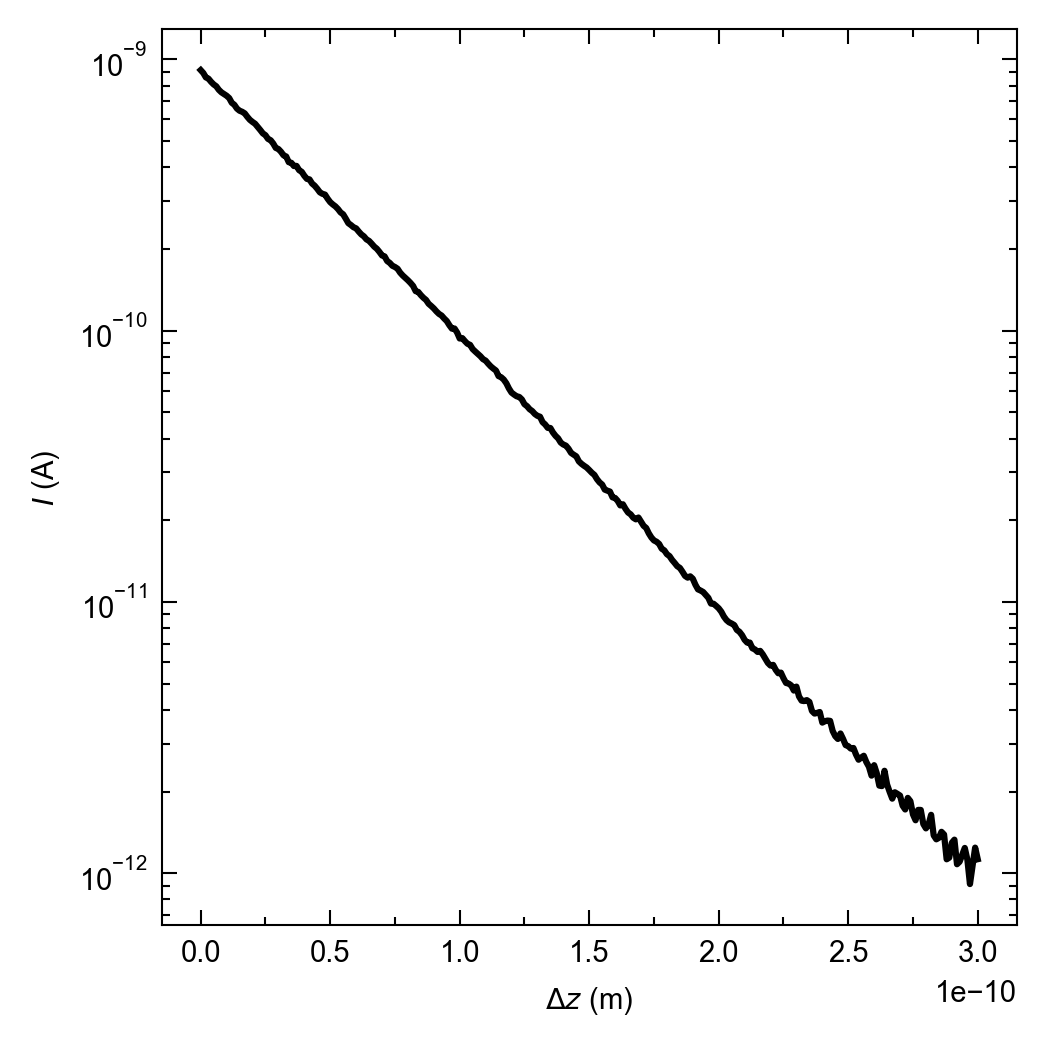

In [6]:
# New API: d.iz.raw()
z2, current2 = data_iz.iz.raw()

fig, axs = plt.subplots(1, 1, figsize=(86/25.4, 86/25.4))
axs.plot(z2, current2, color='k')
axs.set_yscale('log')
axs.set_xlabel(r'$\Delta z$ (m)')
axs.set_ylabel('$I$ (A)')
axs.xaxis.set_minor_locator(AutoMinorLocator(2))
fig.tight_layout(pad=0.5)

## Grid STS example (.3ds) — new API

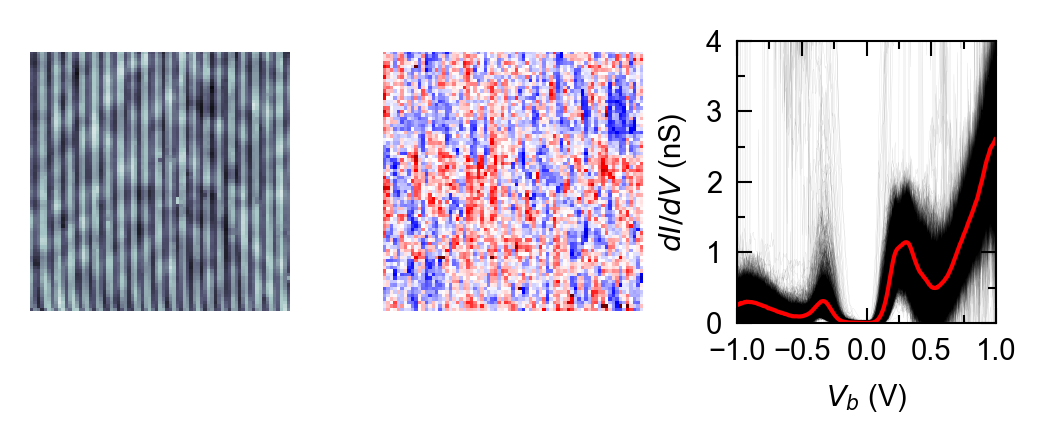

In [7]:
data_gridsts = nr.load(dir + "TNS_STM6_#117_2023.3ds")

# Topography
topo = data_gridsts.topo.subtract_linear_fit()

# dI/dV scaled — full 3D, then slice
V, didv_3d = data_gridsts.sts.scaled()
didvmap = didv_3d[:, :, 115]        # map at mid-bias
all_spectra = didv_3d.reshape(-1, len(V))  # flatten to (N, bias)

fig, axs = plt.subplots(1, 3, figsize=(86/25.4, 35/25.4))

axs[0].imshow(topo, cmap='bone', origin='lower',
              vmin=np.nanmean(topo) - 3*np.nanstd(topo),
              vmax=np.nanmean(topo) + 3*np.nanstd(topo))

axs[1].imshow(didvmap, cmap=bwr(), origin='lower',
              vmin=np.nanmean(didvmap) - 3*np.nanstd(didvmap),
              vmax=np.nanmean(didvmap) + 3*np.nanstd(didvmap))

for i in range(len(all_spectra)):
    axs[2].plot(V, all_spectra[i] * 1e9, color='k', lw=0.05, alpha=0.2)
axs[2].plot(V, np.nanmean(all_spectra, axis=0) * 1e9, color='r', lw=1)

axs[0].set_axis_off()
axs[1].set_axis_off()
axs[2].set_xlabel('$V_b$ (V)')
axs[2].set_ylabel('$dI/dV$ (nS)')
axs[2].xaxis.set_major_locator(MultipleLocator(0.5))
axs[2].xaxis.set_minor_locator(AutoMinorLocator(2))
axs[2].yaxis.set_minor_locator(AutoMinorLocator(2))
axs[2].set_xlim(-1, 1)
axs[2].set_ylim(0, 4)
fig.tight_layout(pad=0.5)

## Grid STS — normalized dI/dV

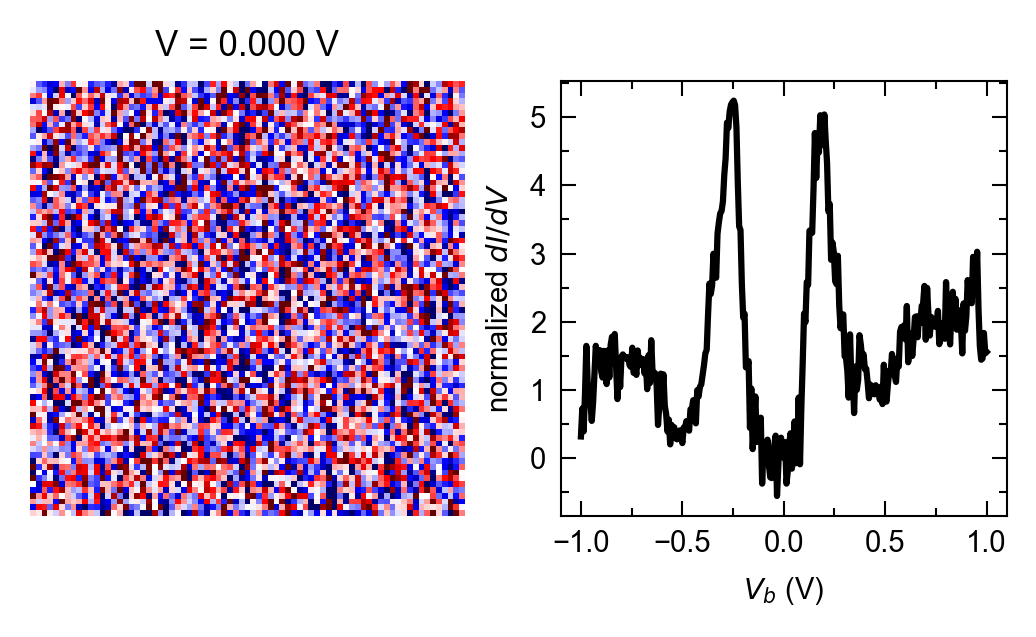

In [8]:
V_n, norm_3d = data_gridsts.sts.normalized(factor=0.2)
norm_map = norm_3d[:, :, len(V_n)//2]

fig, axs = plt.subplots(1, 2, figsize=(86/25.4, 48/25.4))

axs[0].imshow(norm_map, cmap=bwr(), origin='lower',
              vmin=np.nanpercentile(norm_map, 5),
              vmax=np.nanpercentile(norm_map, 95))
axs[0].set_axis_off()
axs[0].set_title(f'V = {V_n[len(V_n)//2]:.3f} V')

# single pixel normalized spectrum
axs[1].plot(V_n, norm_3d[0, 0], color='k')
axs[1].set_xlabel('$V_b$ (V)')
axs[1].set_ylabel('normalized $dI/dV$')
axs[1].xaxis.set_major_locator(MultipleLocator(0.5))
axs[1].xaxis.set_minor_locator(AutoMinorLocator(2))
axs[1].yaxis.set_minor_locator(AutoMinorLocator(2))

fig.tight_layout(pad=0.5)

## Grid I-z example (.3ds) — new API

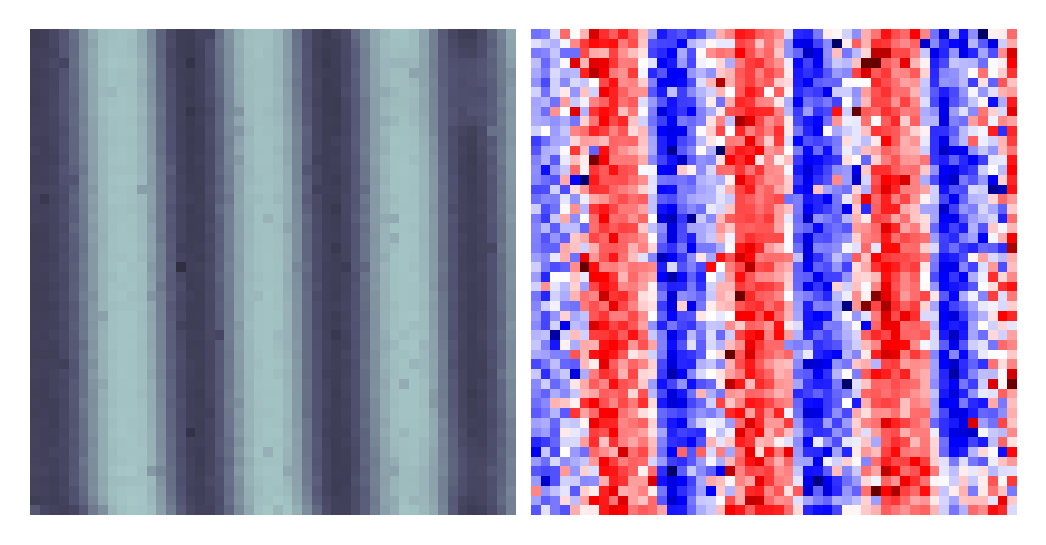

In [9]:
data_gridiz = nr.load(dir + "TNS_STM6_#117_3533.3ds")
topo_iz = data_gridiz.topo.subtract_linear_fit()
barriermap = data_gridiz.iz.barrier_height()

fig, axs = plt.subplots(1, 2, figsize=(86/25.4, 48/25.4))

axs[0].imshow(topo_iz, cmap='bone', origin='lower',
              vmin=np.nanmean(topo_iz) - 3*np.nanstd(topo_iz),
              vmax=np.nanmean(topo_iz) + 3*np.nanstd(topo_iz))

axs[1].imshow(barriermap, cmap=bwr(), origin='lower',
              vmin=np.nanmean(barriermap) - 3*np.nanstd(barriermap),
              vmax=np.nanmean(barriermap) + 3*np.nanstd(barriermap))

axs[0].set_axis_off()
axs[1].set_axis_off()
fig.tight_layout(pad=0.5)